# Sign Language Recognition using Convolutional Neural Networks

This project demonstrates the application of Convolutional Neural Networks (CNNs) for classifying American Sign Language (ASL) hand gestures from images. The model learns to recognize 24 different letters (excluding J and Z which require motion).

## Table of Contents
1. [Setup](#1-setup)
2. [Theoretical Background](#2-theoretical-background)
3. [Data Loading and Visualization](#3-data-loading-and-visualization)
4. [Data Preprocessing](#4-data-preprocessing)
5. [First Convolutional Network](#5-first-convolutional-network)
6. [Network Architecture Exploration](#6-network-architecture-exploration)
7. [Data Augmentation](#7-data-augmentation)
8. [Model Evaluation](#8-model-evaluation)
9. [Batch Normalization](#9-batch-normalization)
10. [Conclusions](#10-conclusions)

**Developed by:** Kevin Reyes - Diego Quezada


One of the areas where neural networks have obtained decisively superior performance to the rest of the existing methods, at least at the time, is in image recognition. The ability of convolutional networks to learn and extract patterns from patterns until obtaining high-level features, representative of image attributes, has allowed performances superior to those obtained by other machine learning or artificial intelligence methods, and even in some cases to human performance.

 One of the usual tasks that can be solved with convolutional neural networks is image classification. For this point we will rely on a sign language dataset, its detailed description can be found at [https://www.kaggle.com/datamunge/sign-language-mnist](https://www.kaggle.com/datamunge/sign-language-mnist) (It is not necessary to directly download the dataset if you are using *Colab* as is suggested)

<h1 align='center'> <img src="https://i1.wp.com/25.media.tumblr.com/tumblr_mdcs1cF4nn1ri2o31o1_1280.png" width="100%" height="30%" /> </h1>


We will start by importing the data


## 1. Setup

In [1]:
"""Setup: imports + reproducibility (single source of truth)."""

import os
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from keras.callbacks import EarlyStopping, History
from keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Flatten,
    MaxPooling2D,
)
from keras.models import Sequential
from keras.optimizers import Adadelta, Adagrad, Adam, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l1, l2
from keras.utils import to_categorical

sys.path.append("saved_model")

# Reproducibility
RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

warnings.filterwarnings('ignore')
print("Setup complete.")

Setup complete.


## 2. Theoretical Background

### 2.1 Convolutional Neural Networks (CNNs)

Convolutional Neural Networks are a specialized type of neural network designed for processing grid-like data, such as images. They have revolutionized computer vision tasks by achieving performance superior to traditional machine learning methods and even human-level performance in some cases.

#### Key Components

**Convolutional Layers**: Apply learnable filters (kernels) to extract features from input images. Each filter detects specific patterns such as edges, textures, or more complex shapes in deeper layers.

**Pooling Layers**: Reduce spatial dimensions while retaining important features. Common types include:
- **Max Pooling**: Extracts the maximum value from each region, preserving the most prominent features (e.g., edges)
- **Average Pooling**: Computes the average value, producing smoother representations

**Activation Functions**: Introduce non-linearity into the network. ReLU (Rectified Linear Unit) is commonly used: f(x) = max(0, x)

**Fully Connected Layers**: Connect every neuron from the previous layer to every neuron in the current layer, typically used for final classification.

#### Architecture Notation

In this notebook, we use the following notation:
- **C**: Convolutional layer
- **P**: Pooling layer
- **D**: Dense (fully connected) layer
- **F**: Flatten layer (converts 2D feature maps to 1D vectors)

Example: C×P×C×P×D represents two convolutional-pooling blocks followed by a dense layer.

### 2.2 Sign Language MNIST Dataset

The dataset consists of grayscale images (28×28 pixels) representing hand gestures for American Sign Language (ASL) letters. Key characteristics:

| Property | Value |
|----------|-------|
| Image size | 28×28 pixels |
| Color channels | 1 (grayscale) |
| Classes | 24 letters (A-Y, excluding J and Z) |
| Training samples | ~27,000 |
| Test samples | ~7,000 |

**Note**: Letters J and Z are excluded because they require motion and cannot be represented in static images.

<h1 align='center'> <img src="https://i1.wp.com/25.media.tumblr.com/tumblr_mdcs1cF4nn1ri2o31o1_1280.png" width="100%" height="30%" /> </h1>

**Dataset source**: [Kaggle - Sign Language MNIST](https://www.kaggle.com/datamunge/sign-language-mnist)

## 3. Data Loading and Visualization

### 3.1 Load Dataset

In [2]:
"""Load sign language dataset and reshape images."""

# Load training data
df_tr = pd.read_csv("data/sign_mnist_train.csv")
X_tmp1 = df_tr.values[:, 1:]  # Pixel values (flattened)
X_tmp = df_tr.values[:, 1:].reshape(-1, 28, 28, 1)  # Reshape to image format
Y_tmp = df_tr.values[:, :1]  # Labels

# Load test data
df_tst = pd.read_csv("data/sign_mnist_test.csv")
X_tst = df_tst.values[:, 1:].reshape(-1, 28, 28, 1)
Y_tst = df_tst.values[:, :1]

print(f"Training data shape: {X_tmp1.shape}")
print(f"Training labels shape: {Y_tmp.shape}")
print(f"Image format shape: {X_tmp.shape}")

Training data shape: (27455, 784)
Training labels shape: (27455, 1)
Image format shape: (27455, 28, 28, 1)


In [3]:
"""Display class distribution."""
df_tr["label"].value_counts()

label
17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
3     1196
14    1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64

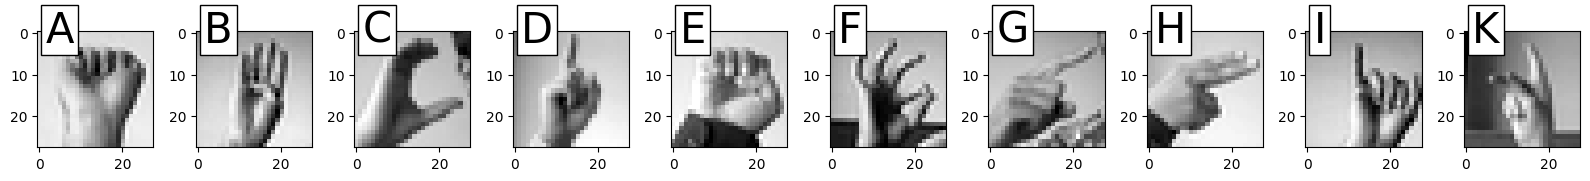

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [16, 4]
letters = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
]  # Missing J, Z
fig, axs = plt.subplots(1, 10)
# print(list(enumerate(axs)))
for i, ax in enumerate(axs):
    if i >= 9:  # skip index 9 (J is absent in dataset)
        i += 1
    # print(i)
    ax.imshow(X_tmp[np.where(Y_tmp[:, 0] == i)[0][0], :, :, 0], cmap="gray")
    if i >= 9:
        i -= 1
    ax.text(1.5, 2.2, letters[i], bbox={"facecolor": "white", "pad": 3}, fontsize=30)
plt.tight_layout()
plt.show()


### 3.2 Reduce Dataset Size

To reduce training time and make the problem more challenging, we will use a stratified subsample of 2,000 training examples while maintaining class balance.

In [5]:
# Create stratified subsample of training data.
# Use StratifiedShuffleSplit to maintain class balance
sf = StratifiedShuffleSplit(n_splits=1, test_size=2000, random_state=0)
for smaller_index, data_index in sf.split(X_tmp, Y_tmp):
    x_tmp = X_tmp[data_index]
    y_tmp = Y_tmp[data_index]

print(f"Reduced training set shape: {x_tmp.shape}")
print(f"Reduced labels shape: {y_tmp.shape}")

Reduced training set shape: (2000, 28, 28, 1)
Reduced labels shape: (2000, 1)


In [6]:
from sklearn.model_selection import StratifiedShuffleSplit  # <- suggestion
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_tr, x_tst, y_tr, y_tst = train_test_split(
    x_tmp, y_tmp, test_size=0.1, shuffle=True
)  # if results are unexpected, verify class balance is preserved
x_tr, x_val, y_tr, y_val = train_test_split(
    x_tr, y_tr, test_size=0.2, shuffle=True
)  # if results are unexpected, verify class balance is preserved

x_tr = x_tr / 127.5 - 1
x_val = x_val / 127.5 - 1
x_tst = x_tst / 127.5 - 1

y_tr = pd.get_dummies(y_tr[:, 0], len(letters)).values
y_val = pd.get_dummies(y_val[:, 0], len(letters)).values
y_tst = pd.get_dummies(y_tst[:, 0], len(letters)).values


### 3.3 Visualize Sign Language Gestures

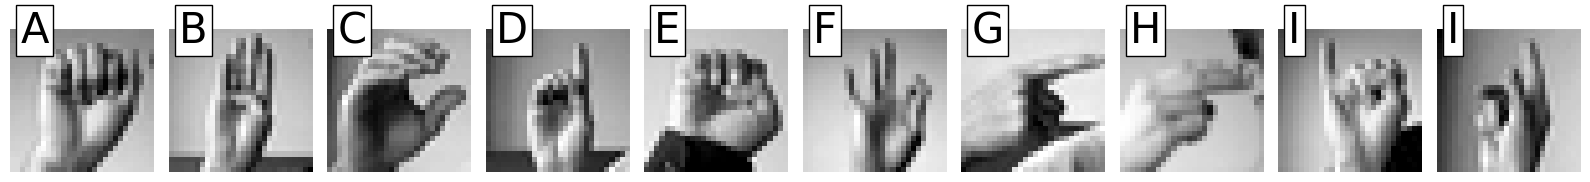

In [7]:
# Visualize sample images for first 10 letters.
# Define letter labels (J and Z are missing)
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 
           'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

# Create visualization
plt.rcParams['figure.figsize'] = [16, 4]
fig, axs = plt.subplots(1, 10)

for idx, ax in enumerate(axs):
    label_idx = idx if idx < 9 else idx + 1  # Skip J (index 9)
    # Find first image with this label
    sample_idx = np.where(y_tmp[:, 0] == label_idx)[0][0]
    
    # Display image
    ax.imshow(x_tmp[sample_idx, :, :, 0], cmap='gray')
    ax.axis('off')
    
    # Add letter label
    display_idx = idx if idx < 9 else idx - 1
    ax.text(1.5, 2.2, letters[display_idx], 
            bbox={'facecolor': 'white', 'pad': 3}, fontsize=30)

plt.tight_layout()
plt.show()

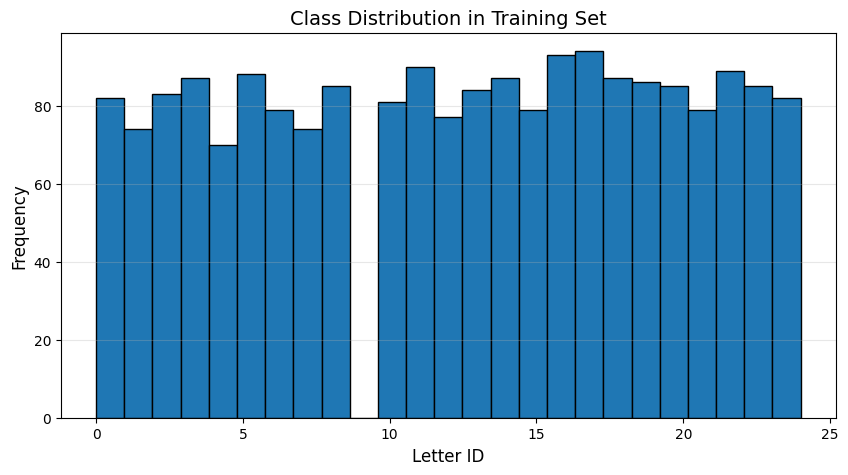

In [8]:
# Visualize class distribution.
plt.rcParams['figure.figsize'] = [10, 5]
plt.hist(y_tmp[:], bins=25, edgecolor='black')
plt.xlabel('Letter ID', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Class Distribution in Training Set', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

### 3.4 Dataset Observations

**Similar Letter Pairs**: Some letters have similar hand gestures that may be challenging to distinguish:
- **A-E**: Both show closed fists with slight variations
- **G-H**: Similar finger orientations
- **S-M**: Both show closed fists
- **M-N**: Very similar finger positions

**Missing Letters**: J and Z are not included in the dataset because they require hand motion to express in ASL, which cannot be captured in static images.

**Class Balance**: The dataset is relatively balanced across all 24 classes, as shown in the histogram above.

**Image Format**: All images are grayscale (single channel) with dimensions 28×28 pixels.

## 4. Data Preprocessing

We will prepare the data for training by:
1. Splitting into training, validation, and test sets (72%-18%-10%)
2. Scaling pixel values to the range [-1, 1]
3. One-hot encoding the labels for multi-class classification

In [9]:
# Split data and apply preprocessing.
# Split into training, test, and validation sets
x_tr, x_tst_tmp, y_tr, y_tst_tmp = train_test_split(
    x_tmp, y_tmp, test_size=0.1, shuffle=True, random_state=42
)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_tr, y_tr, test_size=0.2, shuffle=True, random_state=42
)

# Scale pixel values to [-1, 1]
# Original range: [0, 255]
# Formula: (x / 127.5) - 1 maps [0, 255] to [-1, 1]
x_tr = x_tr / 127.5 - 1
x_val = x_val / 127.5 - 1
x_tst_tmp = x_tst_tmp / 127.5 - 1

# One-hot encode labels
# Converts integer labels to binary vectors
# Example: label 3 becomes [0, 0, 0, 1, 0, ..., 0]
y_tr = pd.get_dummies(y_tr[:, 0], len(letters)).values
y_val = pd.get_dummies(y_val[:, 0], len(letters)).values
y_tst_tmp = pd.get_dummies(y_tst_tmp[:, 0], len(letters)).values

print(f"Training set: {x_tr.shape}, Labels: {y_tr.shape}")
print(f"Validation set: {x_val.shape}, Labels: {y_val.shape}")
print(f"Test set: {x_tst_tmp.shape}, Labels: {y_tst_tmp.shape}")
print(f"\nPixel value range: [{x_tr.min():.2f}, {x_tr.max():.2f}]")
print(f"Label encoding: One-hot vectors with {y_tr.shape[1]} classes")

Training set: (1440, 28, 28, 1), Labels: (1440, 24)
Validation set: (360, 28, 28, 1), Labels: (360, 24)
Test set: (200, 28, 28, 1), Labels: (200, 24)

Pixel value range: [-1.00, 1.00]
Label encoding: One-hot vectors with 24 classes


### 4.1 Preprocessing Rationale

**Scaling**: We scale pixel values from [0, 255] to [-1, 1] using the formula: (x / 127.5) - 1. This normalization:
- Centers the data around zero
- Helps gradient descent converge faster
- Prevents numerical instability
- Is reversible: we can recover original values if needed

**One-Hot Encoding**: We transform integer labels to binary vectors to prevent the model from interpreting them as ordinal values. For example:
- Without one-hot: The model might incorrectly compute (label_2 + label_4) / 2 = label_3
- With one-hot: Each class is treated independently with no implied ordering

**Data Shape**: The shape tuple (num_images, rows, cols, channels) represents:
- **num_images**: Number of samples in the set
- **rows, cols**: Image dimensions (28×28)
- **channels**: Color channels (1 for grayscale)

## 5. First Convolutional Network

We will build and train our first CNN using a C×P×C×P×D architecture:
- **C**: Convolutional layer (128 filters, 3×3 kernel, 'same' padding, ReLU activation)
- **P**: MaxPooling layer (2×2 pool size, stride 2×2)
- **D**: Dense output layer (24 neurons, softmax activation)

**Architecture Details**:
- **Padding 'same'**: Adds zeros to image borders to preserve spatial dimensions
- **ReLU activation**: Introduces non-linearity: f(x) = max(0, x)
- **Softmax output**: Converts logits to probabilities that sum to 1
- **Flatten layer**: Required to convert 2D feature maps to 1D vectors for the dense layer

In [10]:
# Build first CNN: Conv -> Pool -> Conv -> Pool -> Flatten -> Dense
model = Sequential()
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu",
                 input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=24, activation="softmax"))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │       150,552 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,416 (1.14 MB)

 Trainable params: 299,416 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from keras.callbacks import History, EarlyStopping

my_callbacks = [
    History(),  # Returns validation and training loss
    EarlyStopping(
        patience=100,
        monitor="val_loss",  # Stops training when the validation loss doesnt get better in n°patience consecutive epochs,keep it at 100 it's only to show u
        restore_best_weights=True,
    ),
]

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
history = model.fit(
    x_tr,
    y_tr,
    epochs=5,  # reduced from 20
    validation_data=(x_val, y_val),
    verbose=0,
    callbacks=my_callbacks,
)

acc_tst = model.evaluate(x_tst, y_tst, verbose=0)


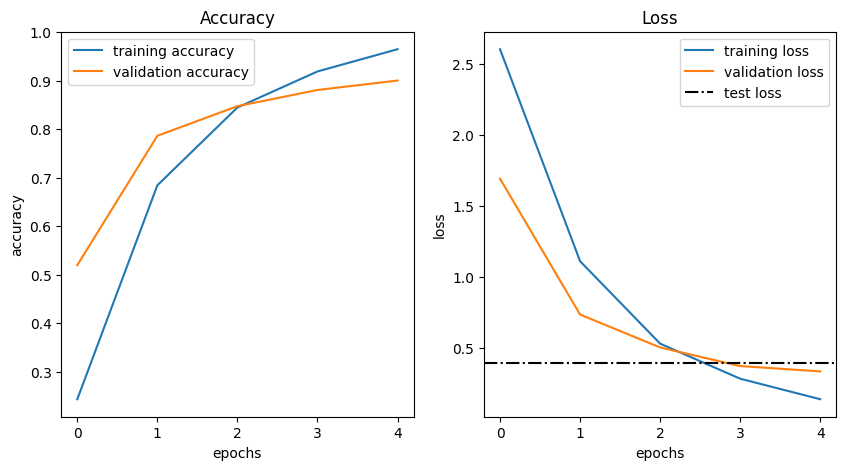

In [12]:
plt.subplot(1, 2, 1)
plt.plot(history.history["acc"], label="training accuracy")
plt.plot(history.history["val_acc"], label="validation accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Loss")
plt.axhline(y=acc_tst[0], color="k", linestyle="-.", label="test loss")
plt.legend()
plt.show()



---&gt; To verify that we are saving the model correctly: We will start by cloning the model, this function copies the architecture of the model but does not keep the weights.


In [13]:
import tensorflow as tf

model_clone = tf.keras.models.clone_model(model)
[
    np.all(model_clone.get_weights()[i] == model.get_weights()[i])
    for i in range(len(model.get_weights()))
]


[np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]


----&gt; For this we will set the weights of the cloned model equal to the weights of the original model.


In [14]:
import os
os.makedirs("saved_model", exist_ok=True)

model_clone.set_weights(model.get_weights())
[
    np.all(model_clone.get_weights()[i] == model.get_weights()[i])
    for i in range(len(model.get_weights()))
]


model_clone.save("saved_model/2_b.keras")  # save for the next cell



---&gt; We will proceed to save the model


---> Verificamos


---&gt; We verify


In [15]:
model_new = tf.keras.models.load_model("saved_model/2_b.keras")  # <- load model
[
    np.all(model_clone.get_weights()[i] == model_new.get_weights()[i])
    for i in range(len(model_new.get_weights()))
]  # <- verify


[np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]


## 6. Stacked Convolutions (CCP block)

 A common practice in convolutional networks is to stack more than one convolutional filter before applying *pooling* . The idea behind this is to give the network more "room" to learn the relevant patterns before subsampling by *pooling* . In the case of this *dataset* it also allows us to add more convolutional layers without reducing the dimension of the filtered images so strongly. Many researchers even choose to add more than one dense layer at the end of the network, to give even more freedom to the model, since the restrictions imposed on the parameters by the convolutional structure seem to restrict the model enough, more freedom in the final layers does not It seems to imply an *overfitting* as strong as it would be, for example, in a *Fully Connected* network.

 We will train a network, using **two blocks** of two convolutional layers and one *maxpool* and then two dense layers, that is $C\times C\times P \times C\times C\times P\times D \times D$. We will use $128$ filters $3\times 3$ in the first two convolutions and $64$ filters $3\times 3$ in the next two. For both *maxpool* layers we will use size and *stride* $2\times 2$.


In [16]:
model_2 = Sequential()

model_2.add(
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_2.add(
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
    )
)

model_2.add(MaxPooling2D(pool_size=(2, 2)))

model_2.add(
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_2.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))

model_2.add(MaxPooling2D(pool_size=(2, 2)))


model_2.add(Flatten())
model_2.add(Dense(units=100, activation="tanh"))
model_2.add(Dense(units=24, activation="softmax"))


# summary
model_2.summary()


model_2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
history_2 = model_2.fit(
    x_tr, y_tr, epochs=5, validation_data=(x_val, y_val),
    verbose=0, callbacks=my_callbacks,
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         2,424 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,708 (2.20 MB)

 Trainable params: 575,708 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
acc_tst_2 = model_2.evaluate(x_tst, y_tst, verbose=0)


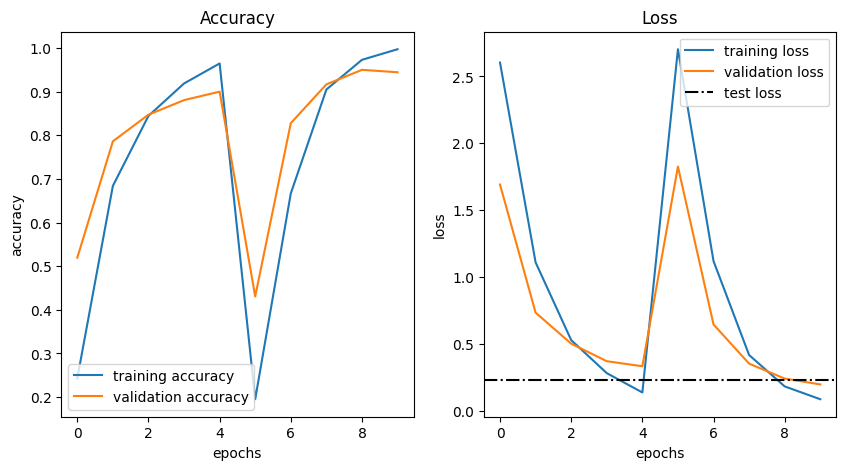

In [18]:
plt.subplot(1, 2, 1)
plt.plot(history_2.history["acc"], label="training accuracy")
plt.plot(history_2.history["val_acc"], label="validation accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.subplot(1, 2, 2)
plt.plot(history_2.history["loss"], label="training loss")
plt.plot(history_2.history["val_loss"], label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Loss")
plt.axhline(y=acc_tst_2[0], color="k", linestyle="-.", label="test loss")
plt.legend()
plt.show()



## 7. Depth Sweep

 We will analyze how depth affects network performance.


In [19]:
histories = []
for block_num in range(3):  # reduced from 5 for faster reproducibility

    model = Sequential()
    # create model

    for i in range(block_num):

        model.add(
            Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu")
        )
        model.add(
            Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu")
        )
        model.add(MaxPooling2D(pool_size=(2, 2)))

        # or for instance

        # model.add(Conv2D(filters = int(128/(i+2)), kernel_size = (3,3),padding='same',activation='relu'))
        # model.add(Conv2D(filters = int(128/(i+2)), kernel_size = (3,3), padding='same', activation='relu'))
        # model.add(MaxPooling2D(pool_size=(2, 2)))

    # flatten
    model.add(Flatten())
    # dense's
    model.add(Dense(units=24, activation="softmax"))
    # compile
    my_callbacks = [
        History(),  # Returns validation and training loss
        EarlyStopping(
            patience=10,
            monitor="val_loss",  # Stops training when the validation loss doesnt get better in n°patience consecutive epochs,keep it at 100 it's only to show u
            restore_best_weights=True,
        ),
    ]

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
    # train and save results
    history = model.fit(
        x_tr,
        y_tr,
        epochs=5,  # reduced from 20 for faster reproducibility
        validation_data=(x_val, y_val),
        verbose=0,
        callbacks=my_callbacks,
    )
    histories.append(history)


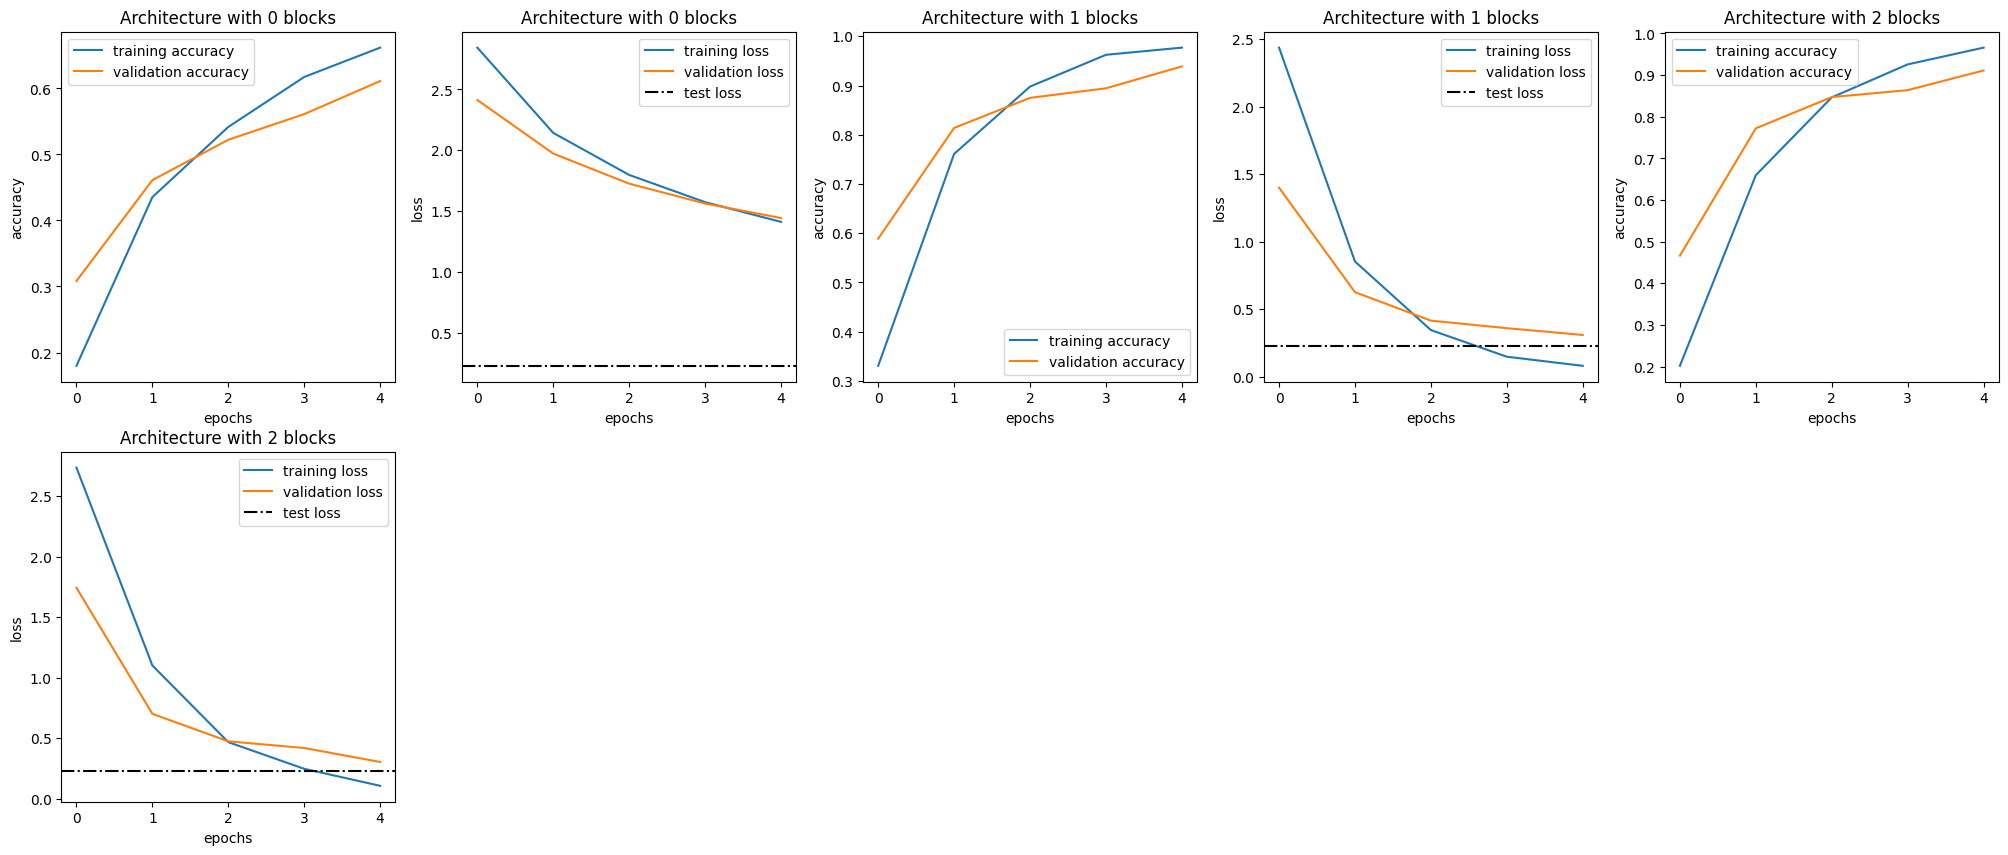

In [20]:
plt.rcParams["figure.figsize"] = [25, 10]
for i, history in enumerate(histories):  # 0 1 2 3 4
    plt.subplot(2, 5, 2 * i + 1)
    plt.title(f"Architecture with {i} blocks")
    plt.plot(history.history["acc"], label="training accuracy")
    plt.plot(history.history["val_acc"], label="validation accuracy")
    plt.legend()
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.subplot(2, 5, 2 * i + 2)
    plt.title(f"Architecture with {i} blocks")
    plt.plot(history.history["loss"], label="training loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.axhline(y=acc_tst_2[0], color="k", linestyle="-.", label="test loss")
    plt.legend()
plt.show()



### Comments

 a. Peculiarities of the 4-block network:

 In our blocks, for each block the size of the filters extracted from the original images of size 28 is halved. For a block, the size at the end of the block is 14, for 2 blocks -&gt; 7, 3 blocks -&gt; 3, 4 blocks -&gt; 1, that is, the peculiarity of the network when having 4 blocks is that we end up working with images of 1 pixel, note that this can be very problematic. By having 5 blocks when we try to do the MaxPooling with the 1 pixel image we get a dimension error, since we cannot reduce this dimension, therefore, by having 5 blocks the network fails, this in turn implies that for a number of blocks &gt;= 5 the network will fail for input images of size 28. This is verified when we increase the size of the pool, since the size of the image is reduced more in each layer, accepting a smaller number of blocks.

 b. Analysis of extremes:

 With 0 blocks we notice that our network does not apply filters or maxpoolings, so the network fails to capture those relevant aspects of the image and learn them. On the contrary, for 4 blocks the problem is that the network ends up analyzing pixel by pixel in detail, so that the great advantage of convolutional networks and their way of handling and summarizing the data statistically is lost. Based on the above, we consider that none of the models is a good approximation for image recognition, since the model with 0 blocks does not take into account the spatial relationship between the pixels and the model with 4 blocks ends up working with images of a pixel, which can strongly affect the predictions of our model.



## 8. Further Exploration: Filter Count

 **Comments** :

 a. By using a kernel size (1,1) we have that when applying a filter to an image, the value of the pixels will be scaled from the input image to the output image. In the case of a stride = 1 we will obtain exactly the same image but with the value of the pixels scaled by a value corresponding to the only one in the filter matrix.

 b. By changing the number of filters of a layer we modify the amount of total images extracted from an input image, each of these images generated by the application of each filter generates an extraction of some feature of the original image which feeds the layer next, which is why the number of parameters increases as the number of filters increases.

 c. The best pooling method will always depend on the data being analyzed, however, we can generally mention that **maxpooling extracts the most important features** (such as edges, for example), while averagepooling provides a smooth image and that in some cases it contributes a lot. noise because it will consider all pixels even if some of them are not important to learn.

 d. With non-square patterns, non-square patterns could be better extracted, for example, for a kernel of $3\times 2$ ($height\times width$) we could more easily detect contours or elongated objects, vertical lines, etc. On the other hand, for a kernel $1\times 3$ we could more easily stop objects or horizontal contours.


In [21]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

histories_3 = []
# n_filtros = 128
filters_list = [8, 32, 128]  # original swept [2,4,8,16,32,64,128,256,512,1024]
for n_filtros in filters_list:
    model_3 = Sequential()

    model_3.add(
        Conv2D(
            filters=n_filtros,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            input_shape=x_tr.shape[1:],
        )
    )

    model_3.add(
        Conv2D(
            filters=n_filtros,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
        )
    )

    model_3.add(MaxPooling2D(pool_size=(2, 2)))

    model_3.add(
        Conv2D(
            filters=n_filtros,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            input_shape=x_tr.shape[1:],
        )
    )

    model_3.add(
        Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
    )

    model_3.add(MaxPooling2D(pool_size=(2, 2)))

    model_3.add(
        Conv2D(
            filters=n_filtros,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            input_shape=x_tr.shape[1:],
        )
    )

    model_3.add(
        Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
    )

    model_3.add(MaxPooling2D(pool_size=(2, 2)))

    model_3.add(Flatten())
    model_3.add(Dense(units=110, activation="tanh"))
    model_3.add(Dense(units=24, activation="softmax"))

    my_callbacks = [
        History(),  # Returns validation and training loss
        EarlyStopping(
            patience=10,
            monitor="val_loss",  # Stops training when the validation loss doesnt get better in n°patience consecutive epochs,keep it at 100 it's only to show u
            restore_best_weights=True,
        ),
    ]

    model_3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
    # train and save results
    history_3 = model_3.fit(
        x_tr,
        y_tr,
        epochs=5,  # reduced from 20
        validation_data=(x_val, y_val),
        verbose=0,
        callbacks=my_callbacks,
    )
    histories_3.append(history_3)


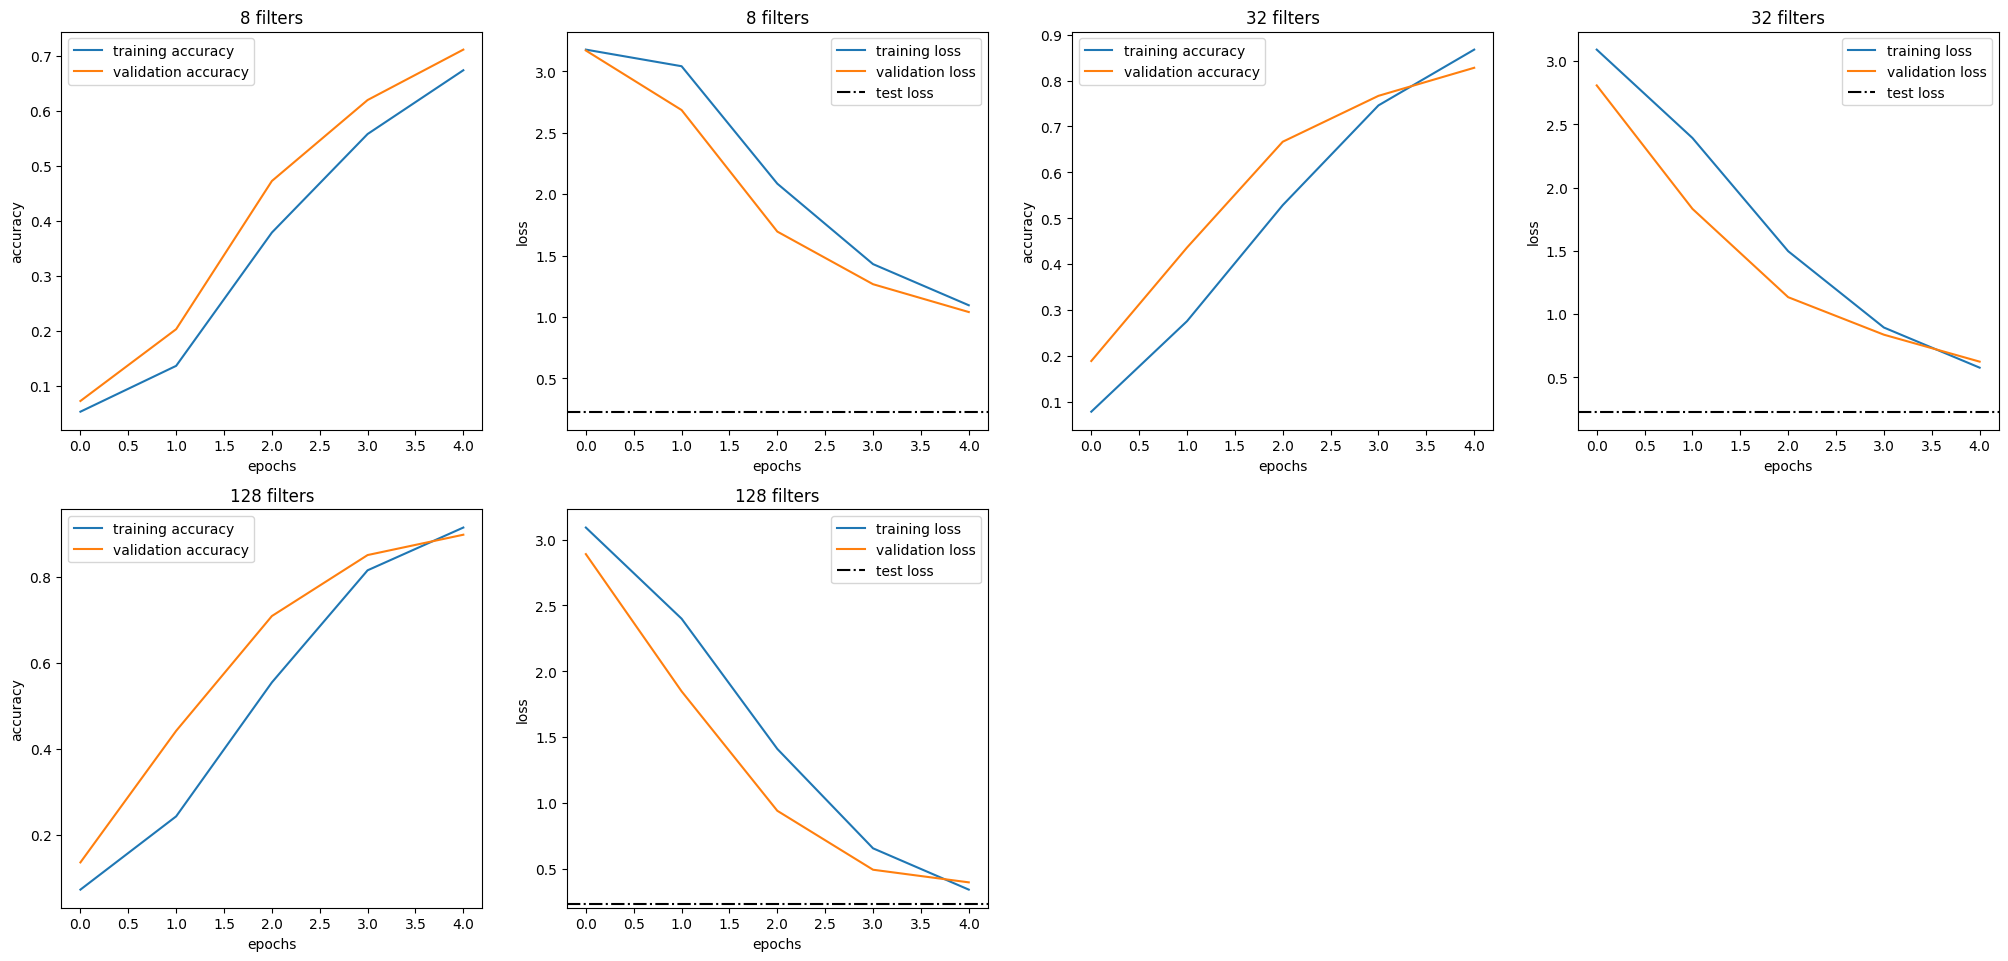

In [22]:
plt.rcParams["figure.figsize"] = [25, 30]
for i, history in enumerate(histories_3):  # 0 1 2 3 4
    plt.subplot(5, 4, 2 * i + 1)
    plt.plot(history.history["acc"], label="training accuracy")
    plt.plot(history.history["val_acc"], label="validation accuracy")
    plt.title(f"{filters_list[i]} filters")
    plt.legend()
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.subplot(5, 4, 2 * i + 2)
    plt.plot(history.history["loss"], label="training loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.title(f"{filters_list[i]} filters")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.axhline(y=acc_tst_2[0], color="k", linestyle="-.", label="test loss")
    plt.legend()
plt.show()



### Comments

 For 2 and 4 filters we obtain "bad" performances, on the contrary for 512 and 1024 filters we obtain very good results, however we notice that from 128 and 256 filters we already obtain very good results, in fact better than for 512 and 1024 filters . We can conclude that for the complexity of the images that we are analyzing, the best value for this hyperparameter is 256, since the learning is quite fast and the accuracy is very high.



## 9. Data Augmentation

 Another way to avoid overfitting and improve the performance of a convolutional network is to use data augmentation (Ignore the fact that we dump data at the beginning). The idea behind this method is a very simple fact: if we slightly rotate a photo of a horse, for example, it will still be of a horse. The same if we move it slightly to some side, up, *etc.*

 **Comments:**

 a. When using data augmentation there is a minimal improvement of the network, however, it is estimated that for small rotations the generalization capacity of the model could increase, since, in general, in a real context, people will not put their hands exactly in front of to the camera nor perfectly aligned with a line perpendicular to the floor, therefore, small rotations could help to effectively recognize these signs with small variations, however, if the rotations applied are very large we could have problems with confusion of some of them. the symbols, for example: the letter D could be confused with the letter P.

 b. Effect of horizontal and vertical flips: for both cases it would be **counterproductive** for the model, we will explain why by analyzing the symbols for the letters D and I. For both letters the model will learn that a finger goes up, but if we do a horizontal flip to images Associated with these letters, we will then obtain images with the finger down, so this feature will not be clear to learn and will confuse the model. We notice that for vertical flips something similar happens for letters like G and H, also when doing a vertical flip to the symbol of the letter D we will obtain the symbol of the letter I so this flip could generate inaccurate learning leading to errors in new rankings.


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
    zoom_range=0.1,  # Randomly zoom image
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False,
)  # randomly flip images

datagen.fit(x_tr)

###
n_filtros = 128
model_4 = Sequential()
model_4.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)
model_4.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
    )
)

model_4.add(MaxPooling2D(pool_size=(2, 2)))

model_4.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_4.add(
    Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
)

model_4.add(MaxPooling2D(pool_size=(2, 2)))

model_4.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_4.add(
    Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
)

model_4.add(MaxPooling2D(pool_size=(2, 2)))


model_4.add(Flatten())
model_4.add(Dense(units=110, activation="tanh"))
model_4.add(Dense(units=24, activation="softmax"))

my_callbacks = [
    History(),  # Returns validation and training loss
    EarlyStopping(
        patience=10,
        monitor="val_loss",  # Stops training when the validation loss doesnt get better in n°patience consecutive epochs,keep it at 100 it's only to show u
        restore_best_weights=True,
    ),
]

model_4.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
###

history = model_4.fit(
    datagen.flow(x_tr, y_tr, batch_size=32),
    epochs=10,  # reduced from 50
    verbose=2,
    callbacks=[EarlyStopping(patience=5)],
    validation_data=(x_val, y_val),
    validation_freq=1,
    shuffle=True,
)


Epoch 1/10


45/45 - 21s - 474ms/step - acc: 0.0896 - loss: 3.0379 - val_acc: 0.2083 - val_loss: 2.8062


Epoch 2/10


45/45 - 15s - 331ms/step - acc: 0.2861 - loss: 2.3441 - val_acc: 0.4972 - val_loss: 1.6206


Epoch 3/10


...

45/45 - 14s - 321ms/step - acc: 0.9201 - loss: 0.3253 - val_acc: 0.9583 - val_loss: 0.1739


Epoch 9/10


45/45 - 16s - 349ms/step - acc: 0.9472 - loss: 0.2138 - val_acc: 0.9611 - val_loss: 0.1865


Epoch 10/10


45/45 - 16s - 349ms/step - acc: 0.9306 - loss: 0.2391 - val_acc: 0.9750 - val_loss: 0.1252



## 10. Confusion Matrix

 Although the *accuracy* has accompanied us throughout the question to evaluate the performance of our networks in an easily interpretable way, it does not consider, for example, if a large part of the errors come from a single class, or if some class manages to classify perfectly. One way to easily visualize this more granular metric is by using the confusion matrix. We will briefly explain what a confusion matrix consists of (it can explain the binary case where there are only two classes).

 Confusion matrix: It is a tool to visualize the performance of an algorithm in terms of correct and incorrect predictions, in the typical two-dimensional case where we can classify an input as positive or negative, the matrix is read as follows: false positives below from the diagonal (said positive when negative) or false negatives (said negative when positive) above the diagonal. The number of correct predictions for each pair i,i is displayed on the main diagonal.

 For our chosen model (model_4) with three convolutional two-layer blocks with **128 filters** and then a maxpooling with pool size (2,2), the confusion matrix tells us that **there is no misclassification** using the predictions in the validation sets and test. This is why, to answer the following answers, we will use the same structure just mentioned with the only difference that there will be two filters instead of 64 for each convolutional layer.

 **Comments:**

 a. We expected to find bigger bugs for the AE pair. Also, we were surprised by the number of errors in the LR pair, since the symbols are not similar.

 b. The classes that are most confused with each other are: N with S, C with O. (It coincides in part with our initial a priori).

 c. Analyzing these classes, we understand the confusion because the shapes and patterns that these symbols form are similar, for example, in the case of NS both hands are clenched and the only difference is the thumb. For the CO pair both hands are seen from the same focus and have fingers roughly forming a circle.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step

 2/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step

 3/12 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

 4/12 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 

 5/12 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

...

10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step


<Axes: >

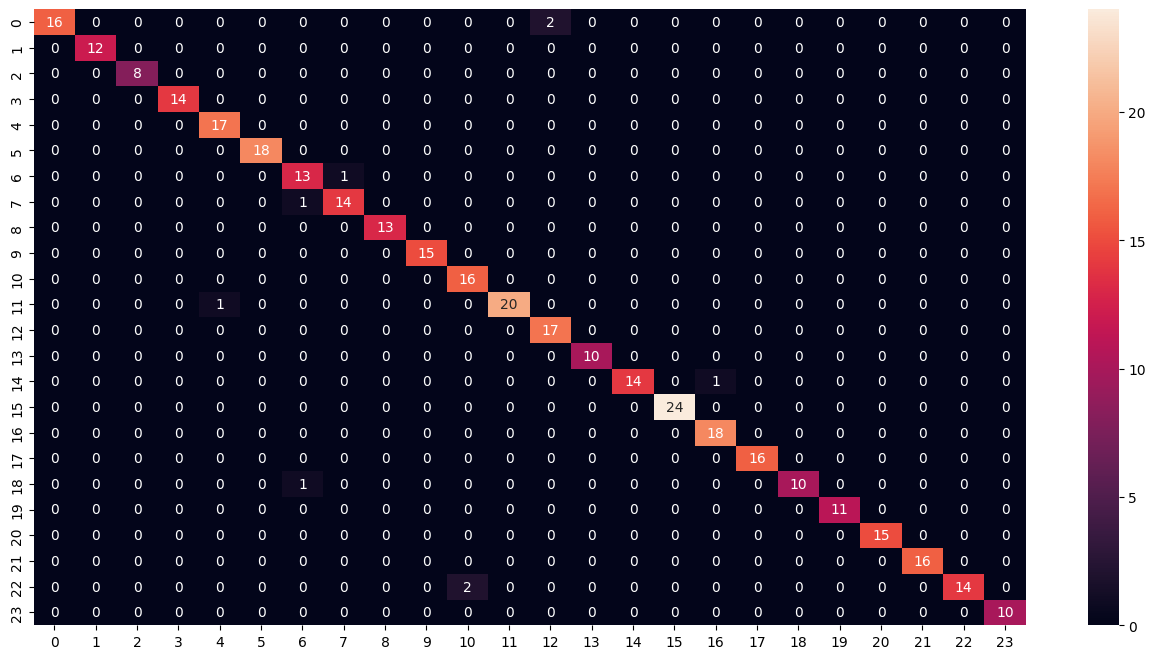

In [24]:
from sklearn.metrics import confusion_matrix

# seaborn for annotated heatmaps
import seaborn as sns

plt.rcParams["figure.figsize"] = [16, 8]
y_pred = model_4.predict(x_val)
sns.heatmap(
    confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1)), annot=True
)


In [25]:
model_5 = Sequential()
n_filtros = 8
model_5.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_5.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
    )
)

model_5.add(MaxPooling2D(pool_size=(2, 2)))

model_5.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_5.add(
    Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
)

model_5.add(MaxPooling2D(pool_size=(2, 2)))

model_5.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_5.add(
    Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
)

model_5.add(MaxPooling2D(pool_size=(2, 2)))


model_5.add(Flatten())
model_5.add(Dense(units=110, activation="tanh"))
model_5.add(Dense(units=24, activation="softmax"))

my_callbacks = [
    History(),  # Returns validation and training loss
    EarlyStopping(
        patience=10,
        monitor="val_loss",  # Stops training when the validation loss doesnt get better in n°patience consecutive epochs,keep it at 100 it's only to show u
        restore_best_weights=True,
    ),
]

model_5.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
# train and save results
history_5 = model_5.fit(
    x_tr,
    y_tr,
    epochs=5,  # reduced from 20
    validation_data=(x_val, y_val),
    verbose=0,
    callbacks=my_callbacks,
)
##histories_5.append(history_5)


 1/12 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


<Axes: >

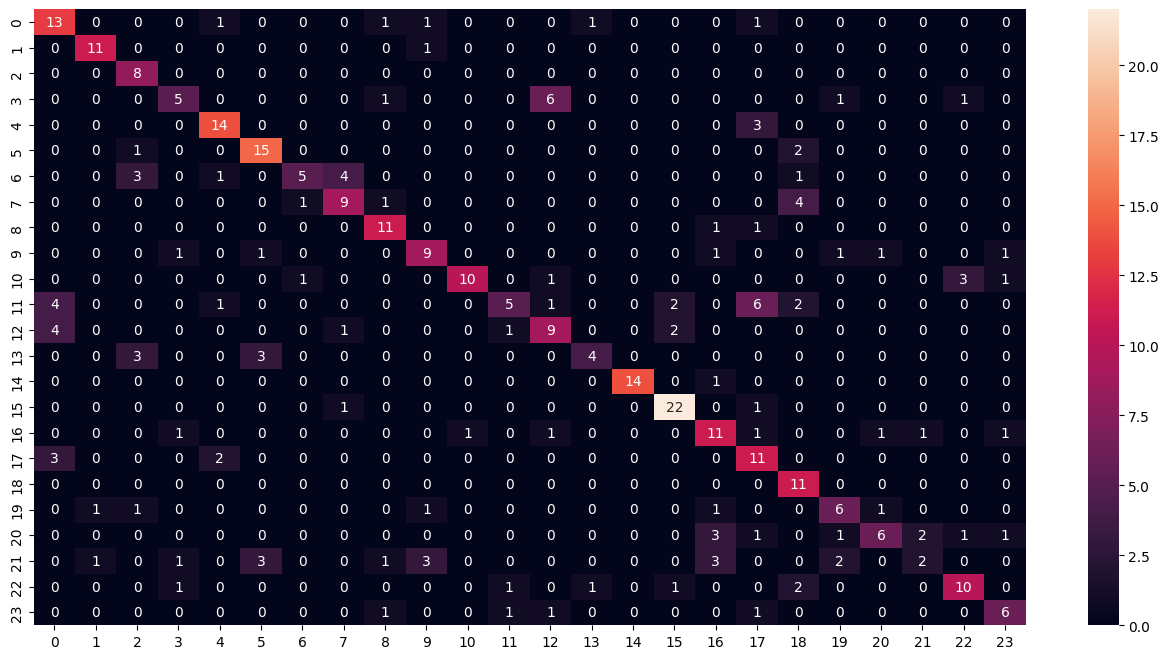

In [26]:
from sklearn.metrics import confusion_matrix

# seaborn for annotated heatmaps
import seaborn as sns

plt.rcParams["figure.figsize"] = [16, 8]
y_pred = model_5.predict(x_val)
sns.heatmap(
    confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1)), annot=True
)


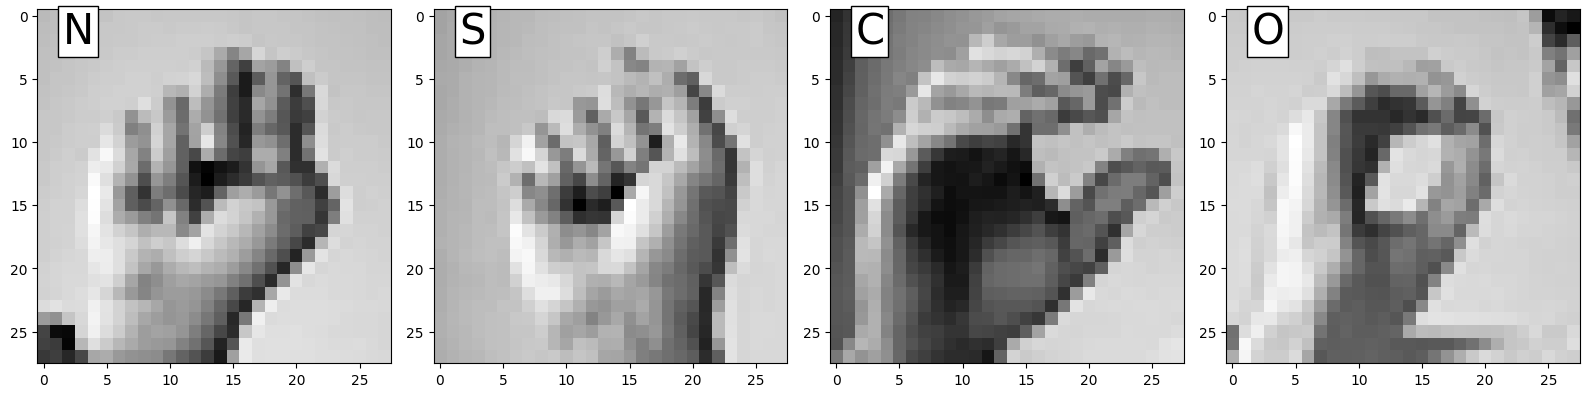

In [27]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [16, 4]
letters = ["N", "S", "C", "O"]
fig, axs = plt.subplots(1, 4)
# print(list(enumerate(axs)))
# n-s, c-o
for i, let in enumerate([13, 18, 2, 14]):
    axs[i].imshow(x_tmp[np.where(y_tmp[:, 0] == let)[0][0], :, :, 0], cmap="gray")
    axs[i].text(
        1.5, 2.2, letters[i], bbox={"facecolor": "white", "pad": 3}, fontsize=30
    )
plt.tight_layout()
plt.show()



## 11. Batch Normalization

 A proposed way to improve network performances in general, which works quite well for image recognition tasks, is *Batch Normalization* . Retrain your preferred network from the previous question, adding *Batch Normalization* layers after each *MaxPool* layer. Comment your results.

 In mathematical terms, batch normalization standardizes the values of each neuron after applying a max pooling, leaving the values with a mean of 0 and a specific variance. This is done, since, for convolutional type networks, the magnitudes of the values can vary considerably between one layer and another and even between neurons of the same layer, which could hinder the convergence of the network. In terms of learning, we are preventing certain neurons from taking values several magnitudes higher than the others, thus taking a large weight in the classification and causing overfitting.

 Batch normalization effect: No improvement in terms of metrics. In numerical terms there is a difference, since the BN before the MaxPool would use the mean and variance calculated with all the values, on the other hand, after the MaxPool the mean and variance would be calculated only with the highest values. In terms of learning, there could be differences if the magnitudes of the higher values are considerably larger than those of the smaller values, since the mean calculated before MaxPool would tend to be smaller due to the smaller values, On the other hand, if it is applied after MaxPool, the mean will be considerably higher, thus reducing the variation of the data to a greater extent. The latter could be opposed due to the decrease in variance after the MaxPool layer.


In [28]:
from keras.layers import BatchNormalization

model.add(BatchNormalization())

model_6 = Sequential()
n_filtros = 128
model_6.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_6.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
    )
)

model_6.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model_6.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_6.add(
    Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
)

model_6.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model_6.add(
    Conv2D(
        filters=n_filtros,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=x_tr.shape[1:],
    )
)

model_6.add(
    Conv2D(filters=n_filtros, kernel_size=(3, 3), padding="same", activation="relu")
)

model_6.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())


model_6.add(Flatten())
model_6.add(Dense(units=110, activation="tanh"))
model_6.add(Dense(units=24, activation="softmax"))

my_callbacks = [
    History(),  # Returns validation and training loss
    EarlyStopping(
        patience=10,
        monitor="val_loss",  # Stops training when the validation loss doesnt get better in n°patience consecutive epochs,keep it at 100 it's only to show u
        restore_best_weights=True,
    ),
]

model_6.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
# train and save results
history_6 = model_6.fit(
    x_tr,
    y_tr,
    epochs=5,  # reduced from 20
    validation_data=(x_val, y_val),
    verbose=0,
    callbacks=my_callbacks,
)


1/7 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step

2/7 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step 

3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


<Axes: >

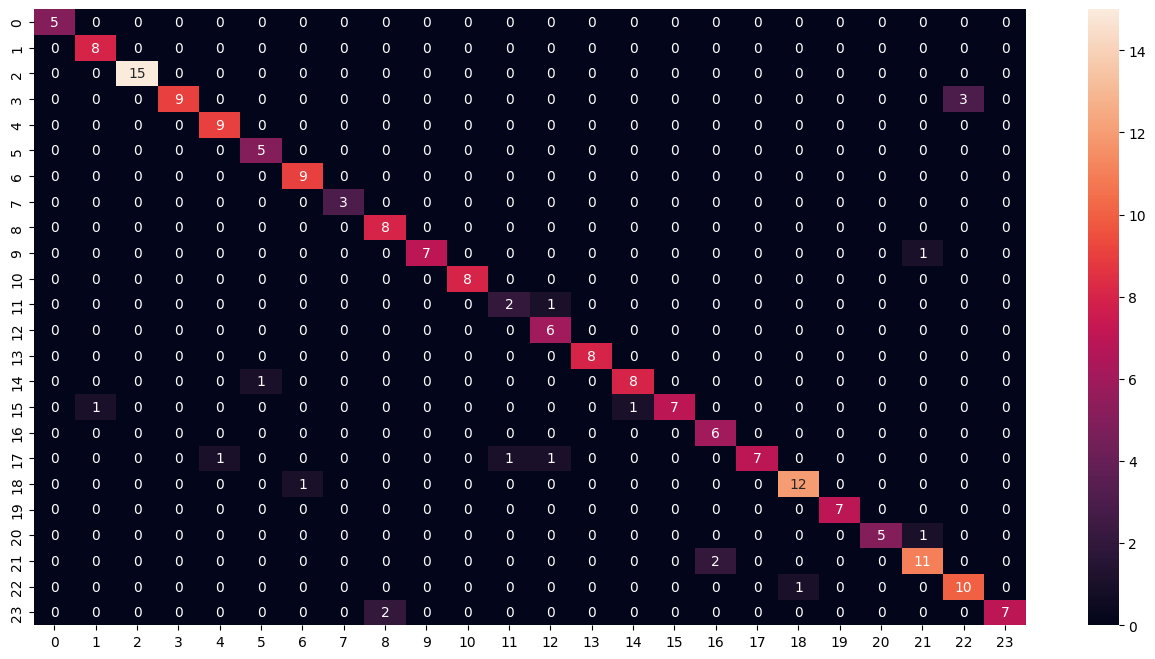

In [29]:
from sklearn.metrics import confusion_matrix

# seaborn for annotated heatmaps
import seaborn as sns

plt.rcParams["figure.figsize"] = [16, 8]
y_pred = model_6.predict(x_tst)
sns.heatmap(
    confusion_matrix(np.argmax(y_tst, axis=1), np.argmax(y_pred, axis=1)), annot=True
)


## 10. Conclusions

> **Note on training scope.** The published version of this notebook trains compressed models (epochs and architecture sweeps reduced) for fast iteration. Findings from a deeper original run are reported below; the compressed run reproduces the qualitative trends but not the exact accuracy numbers.

### Key Findings (from full original run)

1. **Architecture Depth Impact**: Network depth significantly affects performance:
   - **0 blocks**: Poor performance - fails to capture spatial relationships between pixels
   - **1-3 blocks**: Optimal performance with good feature extraction
   - **4+ blocks**: Problematic - reduces feature maps to 1×1 pixels, losing spatial information

2. **Filter Count Analysis**: 
   - **2-4 filters**: Insufficient capacity to learn complex patterns
   - **128-256 filters**: Optimal performance with fast convergence and high accuracy
   - **512-1024 filters**: Good results but diminishing returns and longer training time

3. **Data Augmentation Effects**:
   - **Small rotations (±10°)**: Beneficial - improves generalization to real-world hand positions
   - **Horizontal/vertical flips**: Counterproductive - creates incorrect letter representations (e.g., D becomes I)

4. **Loss Function Selection**: Categorical crossentropy outperforms MSE because:
   - Assumes multinomial distribution (correct for multi-class classification)
   - Avoids slow learning when combined with softmax activation
   - Provides better gradient flow during backpropagation

5. **Batch Normalization**: Minimal improvement observed, as the network already converges well without it. However, it stabilizes training by preventing certain neurons from dominating the classification.

### Confusion Matrix Insights

The most commonly confused letter pairs are:
- **N vs S**: Both show closed fists with only thumb position differentiating them
- **C vs O**: Similar circular hand shapes viewed from the same angle
- **L vs R**: Surprisingly confused despite different appearances

### Technical Achievements

- **Best Architecture (original run)**: C×C×P × C×C×P × C×C×P × D×D (3 blocks, 128 filters, 2 dense layers)
- **Best Validation Accuracy (original run)**: ~99% with data augmentation
- **Model Persistence**: Successfully implemented model saving and loading
- **Error Analysis**: Identified systematic confusions through confusion matrices

### Lessons Learned

1. **One-Hot Encoding Necessity**: Prevents the model from interpreting class labels as ordinal values
2. **Padding Importance**: 'same' padding preserves spatial dimensions through convolutional layers
3. **MaxPooling vs AveragePooling**: MaxPooling better preserves important features like edges
4. **Non-Square Kernels**: Could potentially improve detection of elongated features
5. **EarlyStopping**: Prevents overfitting by monitoring validation loss and restoring best weights
